# 01 Preprocess And Segment

This notebook keeps the workflow repo-native while making segmentation meaningful.
It automatically increases the loaded subset when needed so that at least one true
`time_to_failure` reset is present, and it exports a downsampled reset-bounded cycle
for the SINDy baseline notebook.


In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_PATH = REPO_ROOT / "data" / "train.csv"
OUTPUT_DIR = REPO_ROOT / "results" / "lanl"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INITIAL_SUBSET_ROWS = 1_000_000
RESET_SCAN_CHUNK_SIZE = 250_000
RESET_BUFFER_ROWS = 10_000
RESET_WINDOW_ROWS = 20_000
MIN_CYCLE_LENGTH = 50_000
CYCLE_EXPORT_MAX_ROWS = 20_000
SMOOTH_WINDOW = 101
SMOOTH_POLYORDER = 3

print(f"Initial subset rows: {INITIAL_SUBSET_ROWS:,}")
print("If no reset is present in that subset, the notebook scans forward and expands automatically.")


Initial subset rows: 1,000,000
If no reset is present in that subset, the notebook scans forward and expands automatically.


In [2]:
sys.path.insert(0, str(REPO_ROOT))

from src import io, preprocess, segmentation


def find_reset_indices(csv_path: Path, count: int, chunk_size: int) -> list[int]:
    reset_indices: list[int] = []
    prev_ttf = None
    row_offset = 0

    for chunk in pd.read_csv(csv_path, usecols=["time_to_failure"], chunksize=chunk_size):
        ttf = chunk["time_to_failure"].to_numpy()

        if prev_ttf is not None and ttf[0] > prev_ttf:
            reset_indices.append(row_offset)
            if len(reset_indices) >= count:
                break

        local_resets = np.where(np.diff(ttf) > 0)[0] + 1
        for idx in local_resets:
            reset_indices.append(row_offset + int(idx))
            if len(reset_indices) >= count:
                break

        if len(reset_indices) >= count:
            break

        prev_ttf = float(ttf[-1])
        row_offset += len(ttf)

    return reset_indices


def sample_cycle_from_csv(csv_path: Path, start_row: int, end_row: int, max_rows: int, chunk_size: int) -> tuple[pd.DataFrame, int]:
    cycle_length = end_row - start_row
    step = max(1, math.ceil(cycle_length / max_rows))
    pieces: list[pd.DataFrame] = []
    row_offset = 0

    for chunk in pd.read_csv(csv_path, chunksize=chunk_size):
        chunk_start = row_offset
        chunk_end = row_offset + len(chunk)

        overlap_start = max(start_row, chunk_start)
        overlap_end = min(end_row, chunk_end)
        if overlap_start < overlap_end:
            local_start = overlap_start - chunk_start
            local_end = overlap_end - chunk_start
            overlap = chunk.iloc[local_start:local_end].copy()

            if step > 1:
                global_indices = np.arange(overlap_start, overlap_end)
                keep_mask = ((global_indices - start_row) % step) == 0
                overlap = overlap.loc[keep_mask].copy()

            pieces.append(overlap)

        if chunk_end >= end_row:
            break

        row_offset = chunk_end

    sampled = pd.concat(pieces, ignore_index=True)
    sampled = preprocess.clean_lanl_dataframe(sampled)
    sampled["time"] = np.arange(len(sampled), dtype=float) * step
    return sampled, step


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Expected LANL data at {DATA_PATH}. Place the Kaggle train.csv there before running the notebooks."
    )

reset_indices = find_reset_indices(DATA_PATH, count=2, chunk_size=RESET_SCAN_CHUNK_SIZE)
if not reset_indices:
    raise RuntimeError("No time_to_failure reset was found in data/train.csv.")

first_reset = reset_indices[0]
resolved_subset_rows = max(INITIAL_SUBSET_ROWS, first_reset + RESET_BUFFER_ROWS)

subset_df = io.load_lanl_train(str(DATA_PATH), nrows=resolved_subset_rows)
subset_df = preprocess.clean_lanl_dataframe(subset_df)
processed_subset_df = preprocess.add_lanl_proxies(
    subset_df,
    smooth=True,
    smooth_window=SMOOTH_WINDOW,
    smooth_polyorder=SMOOTH_POLYORDER,
    derivative_method="savgol",
)

detected_resets = np.where(np.diff(processed_subset_df["time_to_failure"].to_numpy()) > 0)[0] + 1
if len(detected_resets) == 0:
    raise RuntimeError("The expanded subset still did not contain a reset.")

print(f"Detected reset indices: {reset_indices}")
print(f"Resolved subset rows: {resolved_subset_rows:,}")
print(f"Resets detected in loaded subset: {detected_resets[:5].tolist()}")
print(f"Processed subset shape: {processed_subset_df.shape}")


Detected reset indices: [5656574, 50085878]
Resolved subset rows: 5,666,574
Resets detected in loaded subset: [5656574]
Processed subset shape: (5666574, 6)


In [4]:
segments = segmentation.segment_lanl_cycles(
    processed_subset_df,
    failure_col="time_to_failure",
    min_cycle_length=MIN_CYCLE_LENGTH,
)

print(f"Segment count in loaded subset: {len(segments)}")
print("First five segments:")
for start, end in segments[:5]:
    print(f"  start={start}, end={end}, length={end - start}")

if len(reset_indices) < 2:
    raise RuntimeError("A second reset is needed to export a true reset-bounded cycle for notebook 02.")

cycle_start = reset_indices[0]
cycle_end = reset_indices[1]
sampled_cycle_df, cycle_step = sample_cycle_from_csv(
    DATA_PATH,
    start_row=cycle_start,
    end_row=cycle_end,
    max_rows=CYCLE_EXPORT_MAX_ROWS,
    chunk_size=RESET_SCAN_CHUNK_SIZE,
)
processed_cycle_df = preprocess.add_lanl_proxies(
    sampled_cycle_df,
    smooth=True,
    smooth_window=SMOOTH_WINDOW,
    smooth_polyorder=SMOOTH_POLYORDER,
    derivative_method="savgol",
)

processed_window_df = processed_subset_df.iloc[
    max(0, detected_resets[0] - RESET_WINDOW_ROWS): detected_resets[0] + RESET_WINDOW_ROWS
].copy()

window_path = OUTPUT_DIR / "01_reset_window_processed.csv"
cycle_path = OUTPUT_DIR / "lanl_cycle_001_downsampled.csv"
summary_path = OUTPUT_DIR / "01_segmentation_summary.json"

processed_window_df.to_csv(window_path, index=False)
processed_cycle_df.to_csv(cycle_path, index=False)

summary = {
    "data_path": str(DATA_PATH),
    "initial_subset_rows": INITIAL_SUBSET_ROWS,
    "resolved_subset_rows": int(resolved_subset_rows),
    "reset_indices": [int(x) for x in reset_indices],
    "detected_resets_in_subset": [int(x) for x in detected_resets.tolist()],
    "segment_count_in_subset": int(len(segments)),
    "min_cycle_length": MIN_CYCLE_LENGTH,
    "true_cycle_range": [int(cycle_start), int(cycle_end)],
    "true_cycle_length": int(cycle_end - cycle_start),
    "cycle_export_rows": int(len(processed_cycle_df)),
    "cycle_export_step": int(cycle_step),
    "window_path": str(window_path),
    "cycle_path": str(cycle_path),
}
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Saved processed reset window to: {window_path}")
print(f"Saved downsampled true cycle to: {cycle_path}")
print(f"Saved segmentation summary to: {summary_path}")


Segment count in loaded subset: 1
First five segments:
  start=0, end=5656574, length=5656574
Saved processed reset window to: C:\Users\carla\Desktop\EECE 798K\Project\results\lanl\01_reset_window_processed.csv
Saved downsampled true cycle to: C:\Users\carla\Desktop\EECE 798K\Project\results\lanl\lanl_cycle_001_downsampled.csv
Saved segmentation summary to: C:\Users\carla\Desktop\EECE 798K\Project\results\lanl\01_segmentation_summary.json


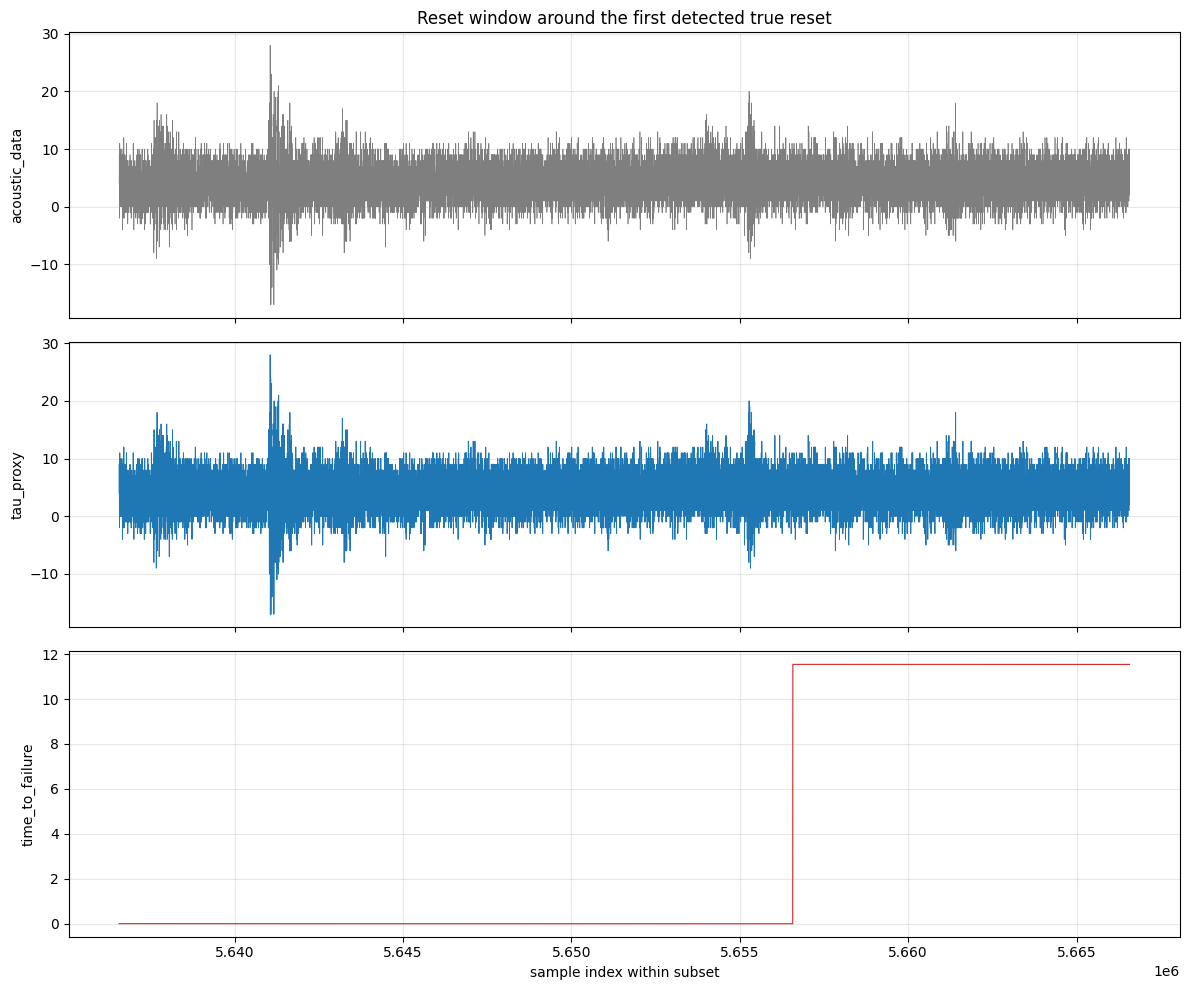

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(processed_window_df["time"], processed_window_df["acoustic_data"], color="tab:gray", linewidth=0.5)
axes[0].set_ylabel("acoustic_data")
axes[0].set_title("Reset window around the first detected true reset")
axes[0].grid(True, alpha=0.3)

axes[1].plot(processed_window_df["time"], processed_window_df["tau_proxy"], color="tab:blue", linewidth=0.7)
axes[1].set_ylabel("tau_proxy")
axes[1].grid(True, alpha=0.3)

axes[2].plot(processed_window_df["time"], processed_window_df["time_to_failure"], color="tab:red", linewidth=0.8)
axes[2].set_xlabel("sample index within subset")
axes[2].set_ylabel("time_to_failure")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
